Tổng số ảnh: 7,000
generator                label_name
imagenet_ai_0419_biggan  fake          500
                         real          500
imagenet_ai_0419_vqdm    fake          500
                         real          500
imagenet_ai_0424_sdv5    fake          500
                         real          500
imagenet_ai_0424_wukong  fake          500
                         real          500
imagenet_ai_0508_adm     fake          500
                         real          500
imagenet_glide           fake          500
                         real          500
imagenet_midjourney      fake          500
                         real          500
dtype: int64
Grid-selected threshold: -149.749
Balanced accuracy: 0.7101428571428572
Khoảng hiển thị 1–99%: [-635.002, 2057.582]


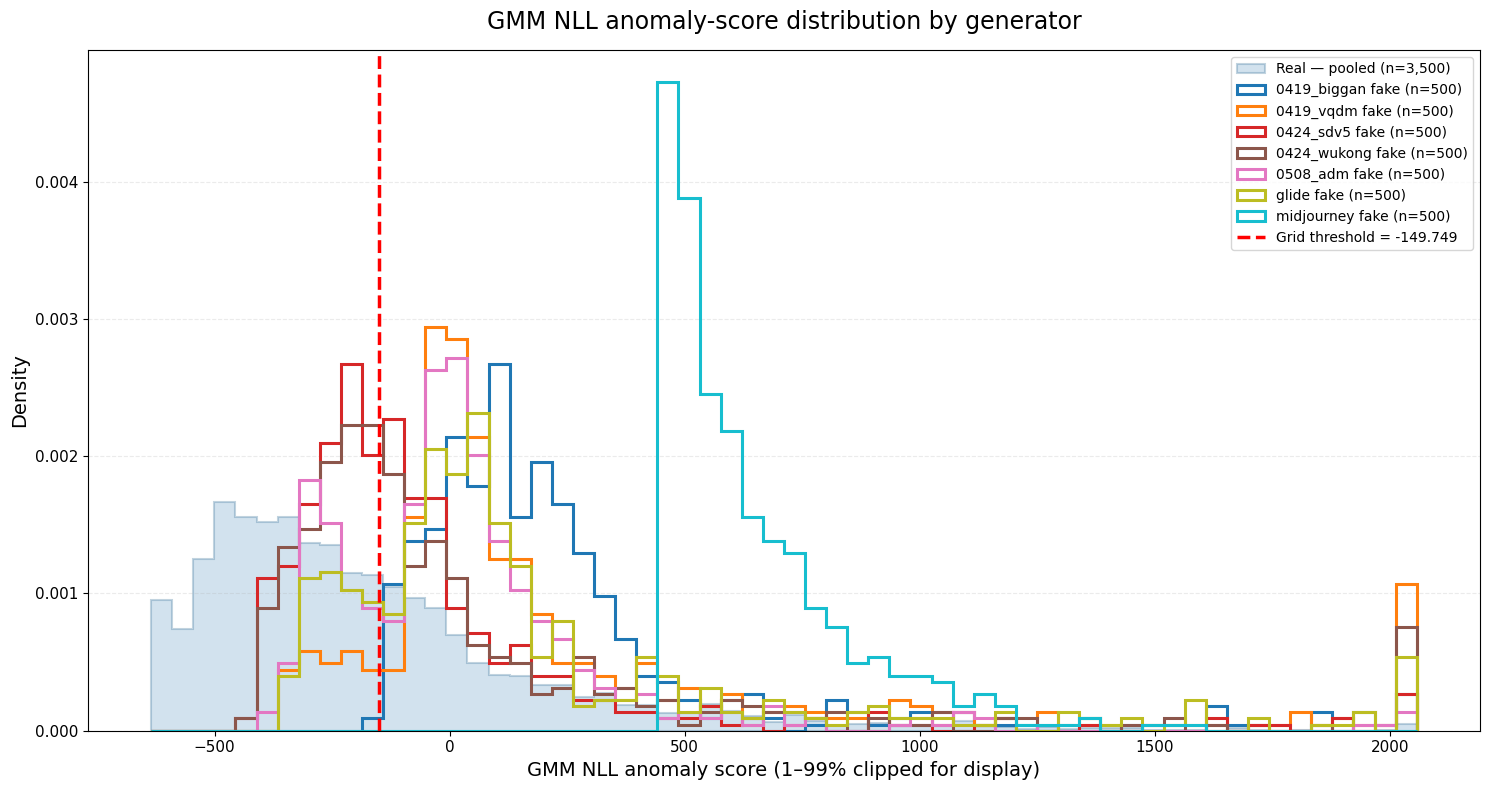

Đã lưu biểu đồ tại:
D:\LLM\LVLM\MLLM_detect_fake_image\HoangHa_Code\baselines\d2_fad\spectral_gmm_branch\output\results\spectral_gmm_tinygenimage_fixed_grid_test\figures\gmm_nll_distribution_by_generator.png


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Đường dẫn
# ============================================================

RESULT_ROOT = Path(
    r"D:\LLM\LVLM\MLLM_detect_fake_image\HoangHa_Code"
    r"\baselines\d2_fad\spectral_gmm_branch\output\results"
    r"\spectral_gmm_tinygenimage_fixed_grid_test"
)

PREDICTION_CSV = (
    RESULT_ROOT
    / "predictions"
    / "tiny_test_predictions.csv"
)

GRID_METRICS_CSV = (
    RESULT_ROOT
    / "metrics"
    / "test_fixed_threshold_grid_metrics.csv"
)

OUTPUT_PATH = (
    RESULT_ROOT
    / "figures"
    / "gmm_nll_distribution_by_generator.png"
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Đọc dữ liệu
# ============================================================

df = pd.read_csv(PREDICTION_CSV)
grid_df = pd.read_csv(GRID_METRICS_CSV)

required_columns = {
    "generator",
    "label",
    "label_name",
    "nll_anomaly_score",
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"CSV thiếu các cột: {sorted(missing_columns)}")

df["nll_anomaly_score"] = pd.to_numeric(
    df["nll_anomaly_score"],
    errors="coerce",
)

df = df.dropna(subset=["nll_anomaly_score"]).copy()

print(f"Tổng số ảnh: {len(df):,}")
print(df.groupby(["generator", "label_name"]).size())


# ============================================================
# 3. Lấy threshold được grid search lựa chọn
# ============================================================

if "selected" in grid_df.columns:
    selected_mask = (
        grid_df["selected"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("true")
    )
else:
    selected_mask = pd.Series(False, index=grid_df.index)

if selected_mask.any():
    selected_row = grid_df.loc[selected_mask].iloc[0]
else:
    # Fallback: chọn threshold có balanced accuracy cao nhất
    selected_row = grid_df.loc[
        grid_df["balanced_accuracy"].idxmax()
    ]

threshold = float(selected_row["threshold"])

print(f"Grid-selected threshold: {threshold:.3f}")
print(
    "Balanced accuracy:",
    float(selected_row["balanced_accuracy"]),
)


# ============================================================
# 4. Giới hạn hiển thị ở percentile 1–99%
# ============================================================

score_column = "nll_anomaly_score"

lower_bound, upper_bound = np.quantile(
    df[score_column],
    [0.01, 0.99],
)

# Clip chỉ để vẽ. Metric và score gốc không bị thay đổi.
df["score_for_plot"] = df[score_column].clip(
    lower=lower_bound,
    upper=upper_bound,
)

print(f"Khoảng hiển thị 1–99%: [{lower_bound:.3f}, {upper_bound:.3f}]")


# ============================================================
# 5. Tạo bins chung
# ============================================================

number_of_bins = 60

bins = np.linspace(
    lower_bound,
    upper_bound,
    number_of_bins + 1,
)

real_scores = df.loc[
    df["label"] == 0,
    "score_for_plot",
]

fake_df = df.loc[df["label"] == 1].copy()

generators = sorted(fake_df["generator"].unique())

colors = plt.cm.tab10(
    np.linspace(0, 1, len(generators))
)


# ============================================================
# 6. Vẽ biểu đồ
# ============================================================

fig, ax = plt.subplots(figsize=(15, 8))

# Phân phối real gộp chung
ax.hist(
    real_scores,
    bins=bins,
    density=True,
    histtype="stepfilled",
    color="#7EAED1",
    alpha=0.35,
    edgecolor="#4F81A4",
    linewidth=1.5,
    label=f"Real — pooled (n={len(real_scores):,})",
)

# Phân phối fake riêng cho từng generator
for color, generator in zip(colors, generators):
    generator_scores = fake_df.loc[
        fake_df["generator"] == generator,
        "score_for_plot",
    ]

    # Rút gọn tên để legend dễ đọc
    display_name = (
        generator
        .replace("imagenet_ai_", "")
        .replace("imagenet_", "")
    )

    ax.hist(
        generator_scores,
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2.2,
        color=color,
        label=f"{display_name} fake (n={len(generator_scores):,})",
    )

# Threshold
ax.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2.5,
    label=f"Grid threshold = {threshold:.3f}",
)


# ============================================================
# 7. Trang trí
# ============================================================

ax.set_title(
    "GMM NLL anomaly-score distribution by generator",
    fontsize=17,
    pad=15,
)

ax.set_xlabel(
    "GMM NLL anomaly score (1–99% clipped for display)",
    fontsize=14,
)

ax.set_ylabel(
    "Density",
    fontsize=14,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax.legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    ncol=1,
)

ax.tick_params(
    axis="both",
    labelsize=11,
)

plt.tight_layout()

plt.savefig(
    OUTPUT_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(f"Đã lưu biểu đồ tại:\n{OUTPUT_PATH}")

Grid-selected threshold: -149.749
Miền hiển thị: -635.00 → 2057.58
Số generator: 7


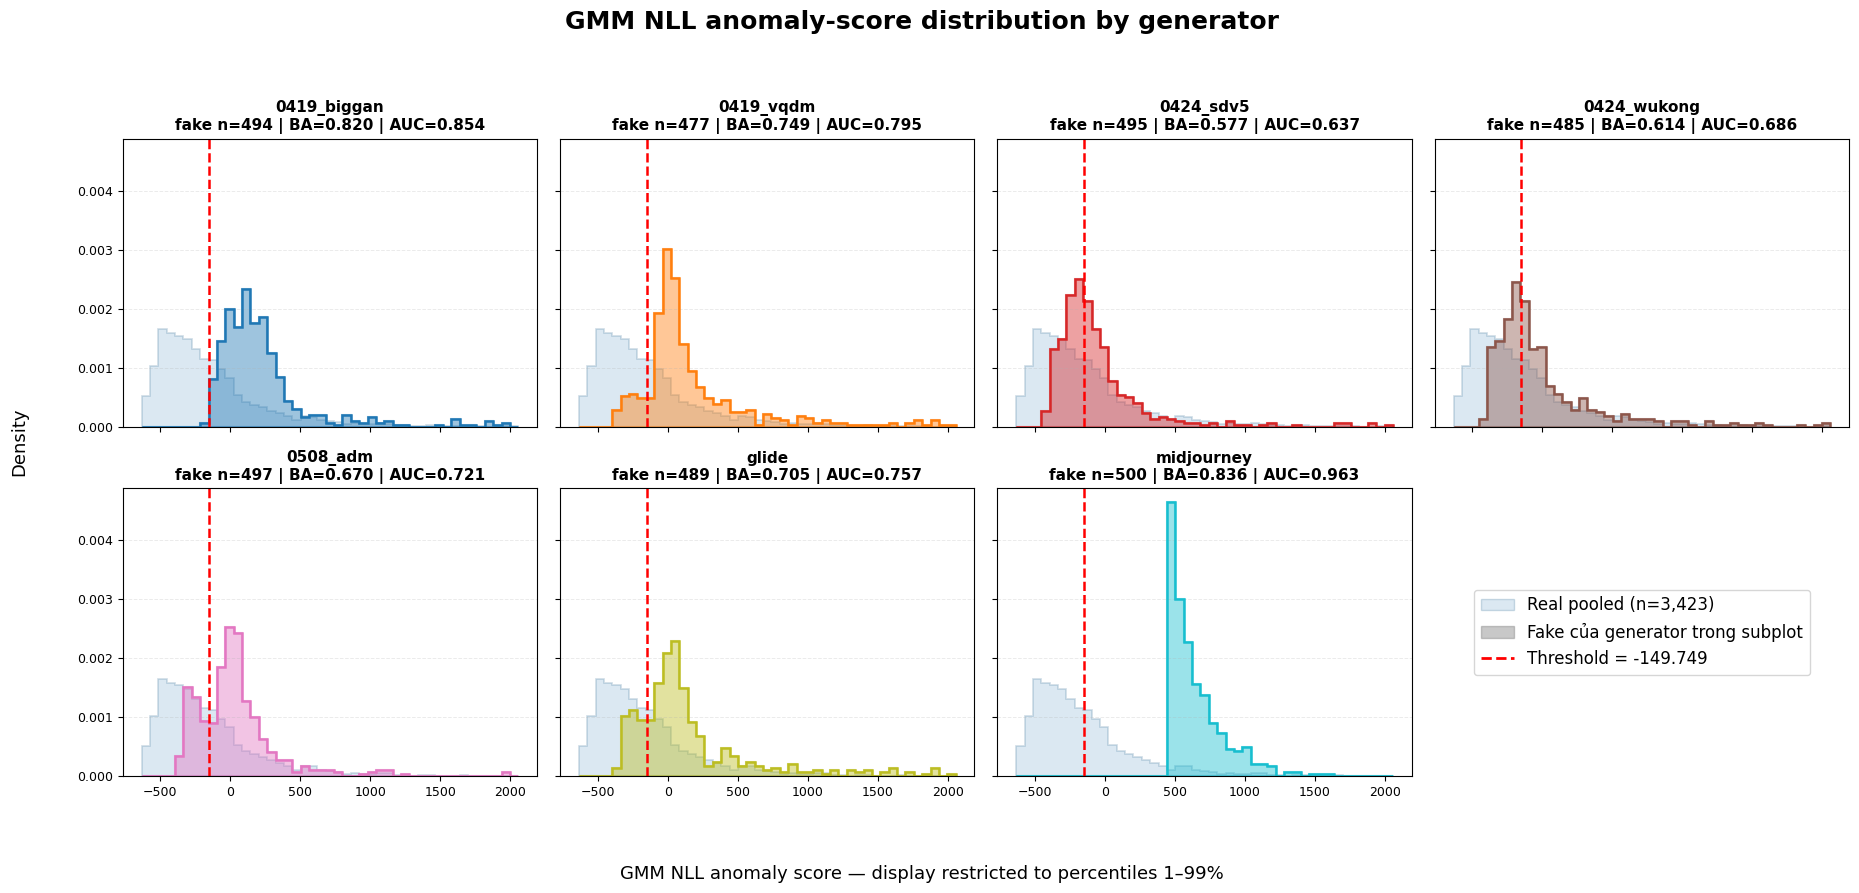

Đã lưu tại:
D:\LLM\LVLM\MLLM_detect_fake_image\HoangHa_Code\baselines\d2_fad\spectral_gmm_branch\output\results\spectral_gmm_tinygenimage_fixed_grid_test\figures\gmm_nll_distribution_generator_subplots.png


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ============================================================
# 1. Đường dẫn
# ============================================================

RESULT_ROOT = Path(
    r"D:\LLM\LVLM\MLLM_detect_fake_image\HoangHa_Code"
    r"\baselines\d2_fad\spectral_gmm_branch\output\results"
    r"\spectral_gmm_tinygenimage_fixed_grid_test"
)

PREDICTION_CSV = (
    RESULT_ROOT
    / "predictions"
    / "tiny_test_predictions.csv"
)

GRID_METRICS_CSV = (
    RESULT_ROOT
    / "metrics"
    / "test_fixed_threshold_grid_metrics.csv"
)

GENERATOR_METRICS_CSV = (
    RESULT_ROOT
    / "metrics"
    / "test_best_grid_generator_metrics.csv"
)

OUTPUT_PATH = (
    RESULT_ROOT
    / "figures"
    / "gmm_nll_distribution_generator_subplots.png"
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Đọc dữ liệu
# ============================================================

df = pd.read_csv(PREDICTION_CSV)
grid_df = pd.read_csv(GRID_METRICS_CSV)
generator_metrics = pd.read_csv(GENERATOR_METRICS_CSV)

score_column = "nll_anomaly_score"

df[score_column] = pd.to_numeric(
    df[score_column],
    errors="coerce",
)

df = df.dropna(subset=[score_column]).copy()


# ============================================================
# 3. Lấy threshold grid-selected
# ============================================================

selected_mask = (
    grid_df["selected"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

if selected_mask.any():
    threshold = float(
        grid_df.loc[selected_mask, "threshold"].iloc[0]
    )
else:
    best_index = grid_df["balanced_accuracy"].idxmax()
    threshold = float(grid_df.loc[best_index, "threshold"])

print(f"Grid-selected threshold: {threshold:.3f}")


# ============================================================
# 4. Miền hiển thị percentile 1–99%
# ============================================================

lower_bound, upper_bound = np.quantile(
    df[score_column],
    [0.01, 0.99],
)

# Chỉ loại khỏi hình những điểm ngoài miền hiển thị.
# Không dùng np.clip để tránh tạo cột giả ở hai biên.
plot_df = df.loc[
    df[score_column].between(lower_bound, upper_bound)
].copy()

number_of_bins = 45

bins = np.linspace(
    lower_bound,
    upper_bound,
    number_of_bins + 1,
)

real_scores = plot_df.loc[
    plot_df["label"] == 0,
    score_column,
]

fake_df = plot_df.loc[
    plot_df["label"] == 1
].copy()

generators = sorted(fake_df["generator"].unique())

print(f"Miền hiển thị: {lower_bound:.2f} → {upper_bound:.2f}")
print(f"Số generator: {len(generators)}")


# ============================================================
# 5. Màu cho từng generator
# ============================================================

palette = plt.cm.tab10(
    np.linspace(0, 1, len(generators))
)

generator_colors = {
    generator: color
    for generator, color in zip(generators, palette)
}


# ============================================================
# 6. Tạo subplot 2 × 4
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(19, 9),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

for index, generator in enumerate(generators):
    ax = axes[index]

    color = generator_colors[generator]

    fake_scores = fake_df.loc[
        fake_df["generator"] == generator,
        score_column,
    ]

    # Real pooled
    ax.hist(
        real_scores,
        bins=bins,
        density=True,
        histtype="stepfilled",
        color="#7EAED1",
        edgecolor="#4F81A4",
        alpha=0.28,
        linewidth=1.2,
    )

    # Fake của generator hiện tại
    ax.hist(
        fake_scores,
        bins=bins,
        density=True,
        histtype="stepfilled",
        color=color,
        edgecolor=color,
        alpha=0.43,
        linewidth=1.5,
    )

    # Vẽ outline để nhìn rõ đường phân phối fake
    ax.hist(
        fake_scores,
        bins=bins,
        density=True,
        histtype="step",
        color=color,
        linewidth=1.8,
    )

    # Threshold
    ax.axvline(
        threshold,
        color="red",
        linestyle="--",
        linewidth=1.8,
    )

    # Lấy metric của generator
    metric_row = generator_metrics.loc[
        generator_metrics["generator"] == generator
    ]

    if not metric_row.empty:
        balanced_accuracy = float(
            metric_row.iloc[0]["balanced_accuracy"]
        )

        roc_auc = float(
            metric_row.iloc[0]["roc_auc"]
        )

        metric_text = (
            f"BA={balanced_accuracy:.3f} | "
            f"AUC={roc_auc:.3f}"
        )
    else:
        metric_text = ""

    display_name = (
        generator
        .replace("imagenet_ai_", "")
        .replace("imagenet_", "")
    )

    ax.set_title(
        f"{display_name}\n"
        f"fake n={len(fake_scores):,} | {metric_text}",
        fontsize=11,
        fontweight="bold",
    )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.25,
    )

    ax.tick_params(
        axis="both",
        labelsize=9,
    )


# ============================================================
# 7. Ô cuối dùng để giải thích ký hiệu
# ============================================================

for unused_index in range(len(generators), len(axes)):
    axes[unused_index].axis("off")

legend_handles = [
    Patch(
        facecolor="#7EAED1",
        edgecolor="#4F81A4",
        alpha=0.28,
        label=f"Real pooled (n={len(real_scores):,})",
    ),
    Patch(
        facecolor="gray",
        edgecolor="gray",
        alpha=0.43,
        label="Fake của generator trong subplot",
    ),
    Line2D(
        [0],
        [0],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Threshold = {threshold:.3f}",
    ),
]

# Đặt legend trong ô thứ 8 nếu còn trống
if len(generators) < len(axes):
    legend_ax = axes[-1]
    legend_ax.axis("off")
    legend_ax.legend(
        handles=legend_handles,
        loc="center",
        fontsize=12,
        frameon=True,
    )


# ============================================================
# 8. Tiêu đề và nhãn chung
# ============================================================

fig.suptitle(
    "GMM NLL anomaly-score distribution by generator",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

fig.supxlabel(
    "GMM NLL anomaly score — display restricted to percentiles 1–99%",
    fontsize=13,
)

fig.supylabel(
    "Density",
    fontsize=13,
)

plt.tight_layout(
    rect=[0.03, 0.05, 1.0, 0.94]
)

plt.savefig(
    OUTPUT_PATH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()

print(f"Đã lưu tại:\n{OUTPUT_PATH}")